<a href="https://colab.research.google.com/github/RiznoFadhil/ui-greenmetric-sustainability-analysis/blob/main/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# UI GreenMetric Mini Project
# Trend & Indicator Contribution Analysis
# Dataset: UI GreenMetric Overall Rankings 2020–2022
# ============================================

In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 2. Load dataset
file_path = "UI_GreenMetric_Overall_Rankings_2020_2022.xlsx"
df = pd.read_excel(file_path)

In [3]:
# 3. Initial data inspection
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      2917 non-null   int64 
 1   Rank                      2917 non-null   int64 
 2   University                2917 non-null   object
 3   Country                   2917 non-null   object
 4   Total Score               2917 non-null   int64 
 5   Setting & Infrastructure  2917 non-null   int64 
 6   Energy & Climate Change   2917 non-null   int64 
 7   Waste                     2917 non-null   int64 
 8   Water                     2917 non-null   int64 
 9   Transportation            2917 non-null   int64 
 10  Education & Research      2917 non-null   int64 
dtypes: int64(9), object(2)
memory usage: 250.8+ KB
None

First 5 rows:
   Year  Rank                        University         Country  Total Score  \
0  2020     1  Wageningen

In [4]:
# 4. Define indicator columns
indicator_cols = [
    "Setting & Infrastructure",
    "Energy & Climate Change",
    "Waste",
    "Water",
    "Transportation",
    "Education & Research"
]

In [5]:
# 5. Data validation: check total score consistency
df["calculated_total"] = df[indicator_cols].sum(axis=1)
df["score_difference"] = df["Total Score"] - df["calculated_total"]

print("\nTotal score validation summary:")
print(df["score_difference"].describe())


Total score validation summary:
count    2917.000000
mean        0.034282
std         1.851534
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       100.000000
Name: score_difference, dtype: float64


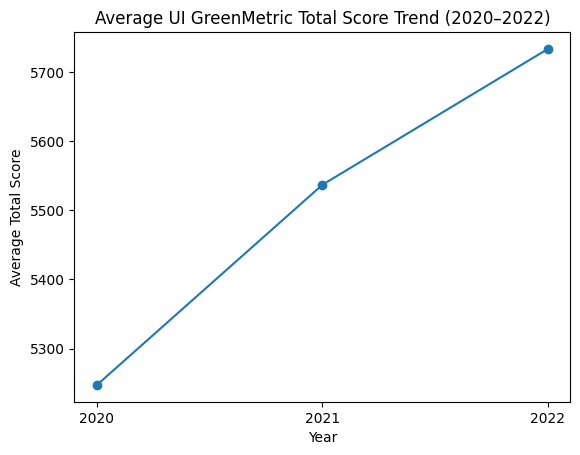

In [7]:
# 6. Trend analysis: average total score per year
trend = df.groupby("Year")["Total Score"].mean().reset_index()

plt.figure()
plt.plot(trend["Year"], trend["Total Score"], marker="o")
plt.title("Average UI GreenMetric Total Score Trend (2020–2022)")
plt.xlabel("Year")
plt.ylabel("Average Total Score")
plt.xticks(trend["Year"])
plt.show()

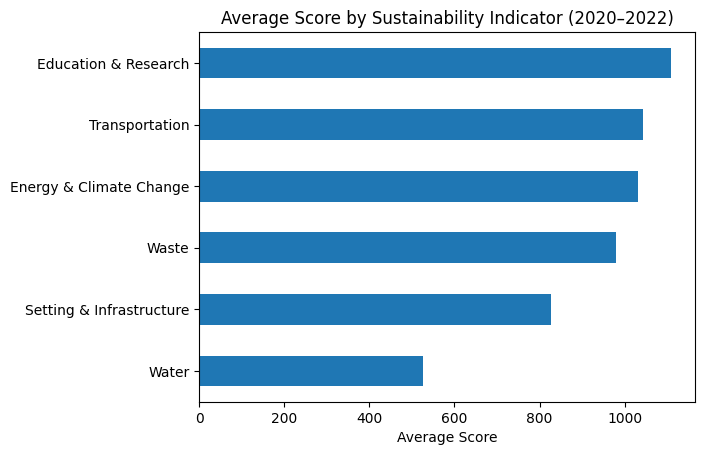

In [8]:
# 7. Indicator contribution analysis
indicator_means = df[indicator_cols].mean().sort_values()

plt.figure()
indicator_means.plot(kind="barh")
plt.title("Average Score by Sustainability Indicator (2020–2022)")
plt.xlabel("Average Score")
plt.show()

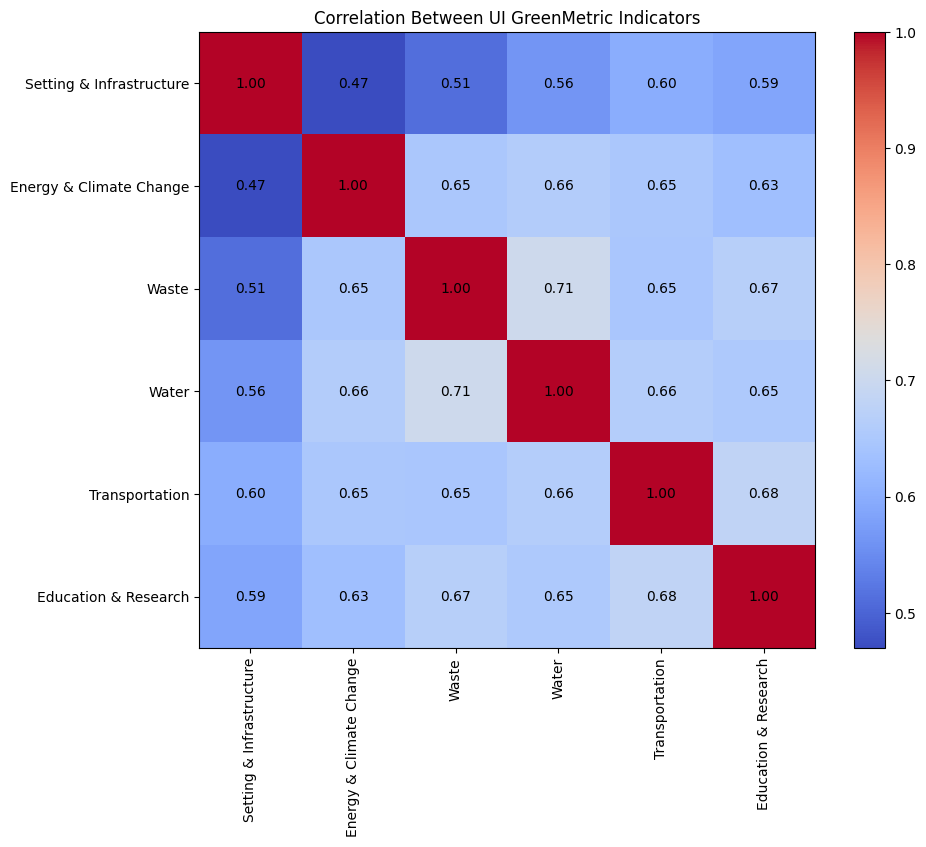

In [11]:
# 8. Correlation analysis between indicators
corr = df[indicator_cols].corr()

plt.figure(figsize=(10, 8)) # Increased figure size for better readability
plt.imshow(corr, cmap='coolwarm', interpolation='nearest') # Added colormap
plt.xticks(range(len(indicator_cols)), indicator_cols, rotation=90)
plt.yticks(range(len(indicator_cols)), indicator_cols)
plt.colorbar()

# Add correlation coefficients to the plot
for i in range(len(indicator_cols)):
    for j in range(len(indicator_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=10) # Increased font size to 10

plt.title("Correlation Between UI GreenMetric Indicators")
plt.show()

In [15]:
# 11. Identify and visualize top correlating indicator pairs
import numpy as np

# Get the upper triangle of the correlation matrix to avoid duplicates and self-correlation
upp_mat = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Convert to a stacked series and drop NA values
upp_mat_stacked = upp_mat.stack()

# Convert to DataFrame and reset index
correlation_pairs = upp_mat_stacked.reset_index()
correlation_pairs.columns = ['Indicator1', 'Indicator2', 'Correlation']

# Sort by correlation in descending order
top_correlations = correlation_pairs.sort_values(by='Correlation', ascending=False).head(10)

print("Top 10 Correlating Indicator Pairs:")
print(top_correlations)

# Create a new column for pair labels for plotting
top_correlations['Pair'] = top_correlations['Indicator1'] + ' - ' + top_correlations['Indicator2']

Top 10 Correlating Indicator Pairs:
                 Indicator1            Indicator2  Correlation
9                     Waste                 Water     0.705198
14           Transportation  Education & Research     0.681534
11                    Waste  Education & Research     0.667619
12                    Water        Transportation     0.662881
6   Energy & Climate Change                 Water     0.661526
13                    Water  Education & Research     0.652988
5   Energy & Climate Change                 Waste     0.649724
7   Energy & Climate Change        Transportation     0.649286
10                    Waste        Transportation     0.647149
8   Energy & Climate Change  Education & Research     0.632757


/tmp/ipython-input-1804988111.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y='Pair', data=top_correlations, palette='viridis')


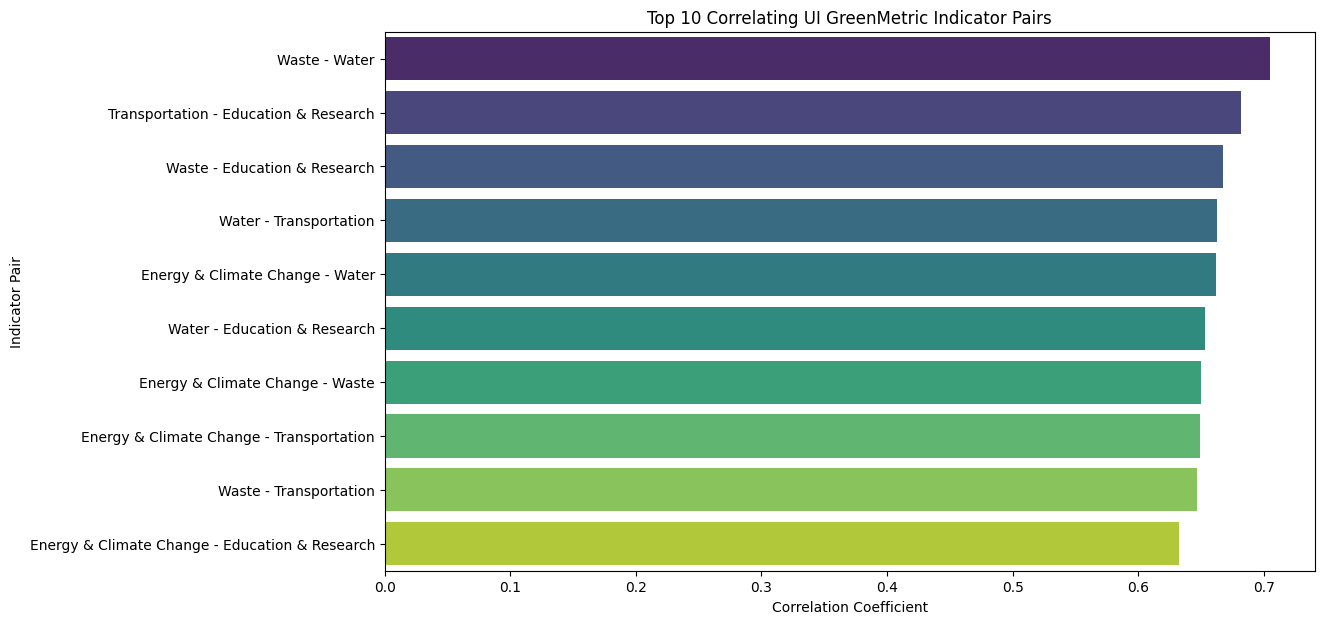

In [16]:
import numpy as np
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Correlation', y='Pair', data=top_correlations, palette='viridis')
plt.title('Top 10 Correlating UI GreenMetric Indicator Pairs')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Indicator Pair')
plt.show()

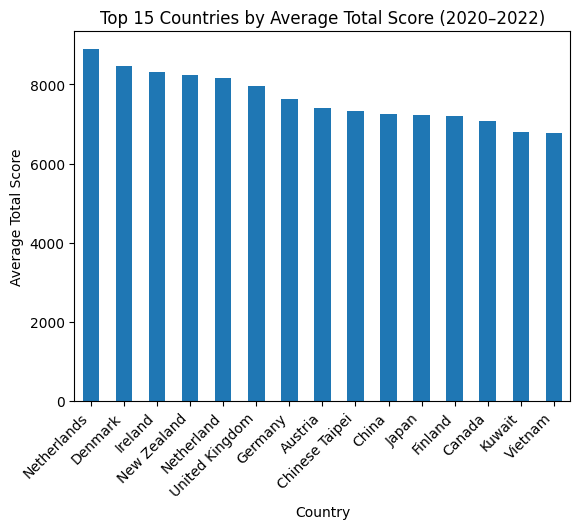

In [12]:
# 9. Regional benchmarking (based on country frequency)
regional_avg = df.groupby("Country")["Total Score"].mean().sort_values(ascending=False)

plt.figure()
regional_avg.head(15).plot(kind="bar")
plt.title("Top 15 Countries by Average Total Score (2020–2022)")
plt.ylabel("Average Total Score")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
# 10. Key insights summary
print("\nKey Insights:")
print("- Average sustainability scores increased consistently from 2020 to 2022.")
print("- Education & Research is the highest contributing indicator on average.")
print("- Water and Setting & Infrastructure have the lowest average scores.")
print("- Some indicators show moderate correlation, suggesting interconnected sustainability efforts.")